In [1]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append("../")
from utils.utils import *
import matplotlib.pyplot as plt
import seaborn as sns
from src.fbsc import plot_signal_drift
from joblib import Parallel,delayed
from tqdm.notebook import tqdm 
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV,LeaveOneOut
import warnings

# Why should this be done before BH correction? 

- If QC samples are to be utilized to correct for batch effects they must first be corrected for their own inherent technical variation, otherwise you will be incorporating that technical variation into your corrections

In [66]:
D = pd.read_csv("../data/2-first-13-AOU.csv").set_index('name').drop(columns=['position','height','mz'])
D = D.loc[:,D.columns.str.contains(".mzML area")]
D.columns = D.columns.str.replace(".mzML area","")
D = D.replace(0,np.nan)
min_val = D.min().min() * .10
D = D.T
M = pd.read_csv("../data/sample_metadata_all_batches_processed_samples.csv")
M = M.set_index("sample_name")
M['batch'] = M['batch'].str.split("_",expand=True)[1].astype(int)
M = M[M['batch'] <= 13]
D = D.loc[D.index]

In [81]:
M[M['sample_type'] == 'sp']['batch'].value_counts()

batch
1     9
2     9
3     9
4     9
5     9
6     9
7     9
8     9
9     9
10    9
11    9
12    9
13    9
Name: count, dtype: int64

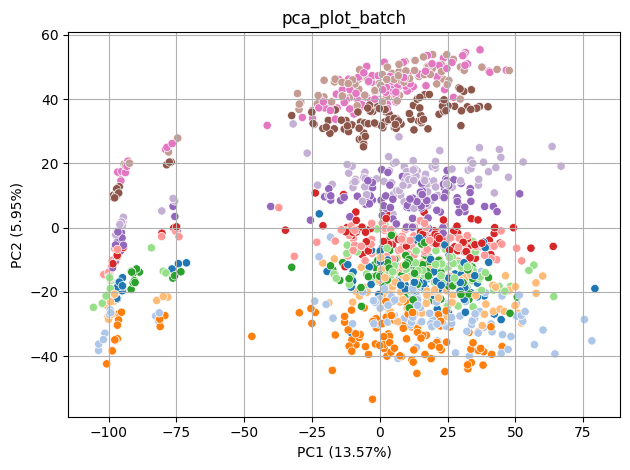

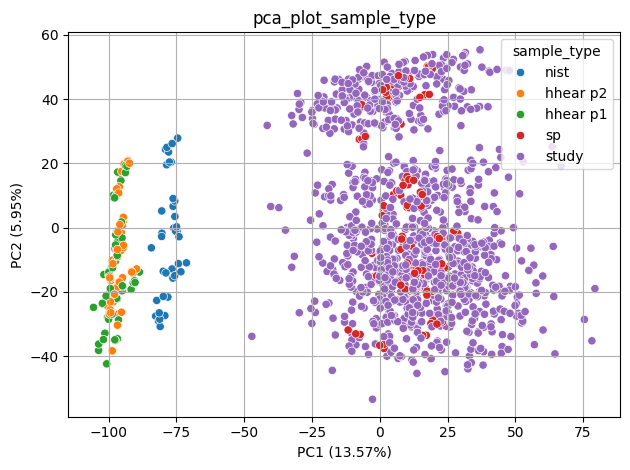

,PC1,PC2,batch,sample_type
AOU_NIST_019,-80.357116,-1.758275,7,nist
AOU_NIST_010,-82.276081,-22.681395,4,nist
AOU_NIST_013,-76.317315,-15.729905,5,nist
AOU_NIST_016,-84.255006,-6.315868,6,nist
AOU_NIST_022,-80.463547,-2.788566,8,nist
...,...,...,...,...
AOU_SP_036,17.386166,-20.990766,4,sp
AOU_SP_081,15.661131,10.275339,9,sp
AOU_SP_0117,1.089908,42.870681,13,sp
AOU_SP_045,12.855684,-14.223896,5,sp


In [69]:
pca_plot(TIC(D.fillna(min_val)),M,hues=['batch','sample_type'],plot_without_blanks=True)

# RSD Distribution of QC Samples 

In [70]:
def RSD(D):
    if D.shape[0] > D.shape[1]:
        raise warnings.warn('Is Data of shape (n_samples,n_signals)?')
    value = (D.std(axis=0) / D.mean(axis=0)) * 100
    print(f'Median RSD: {value.median()}')
    return value
def rsd_distribution(D,M,batch=None):
    QC = D[D.index.str.contains("_SP_")]
    Bio = D[~D.index.str.contains("_SP_")]
    if isinstance(batch,int):
        plt.title(f"RSD Distribution of QC Features in batch {batch}")
        batch_QC = QC.groupby(M['batch']).get_group(batch)
        sns.histplot(RSD(batch_QC))
    elif isinstance(batch,list):
        batch_QC = QC.groupby(M['batch'])
        plt.title(f"RSD Distribution of QC Features per batch")
        for i in batch:
            batch_ = batch_QC.get_group(i)
            sns.kdeplot(RSD(batch_),label=i,legend=True)
            plt.legend()
    else:
        plt.title("RSD Distribution of QC Features across batches")
        sns.histplot(RSD(QC))



Median RSD: 16.353082163049685
Median RSD: 17.06866419779716
Median RSD: 17.019470561955735
Median RSD: 17.293737514177867
Median RSD: 15.823161990987323
Median RSD: 16.566406978325638
Median RSD: 17.058131537672935
Median RSD: 18.204656028610547
Median RSD: 19.31819693262895
Median RSD: 17.61404888467826
Median RSD: 20.027114010948154
Median RSD: 18.524132063320867
Median RSD: 17.839161338040277


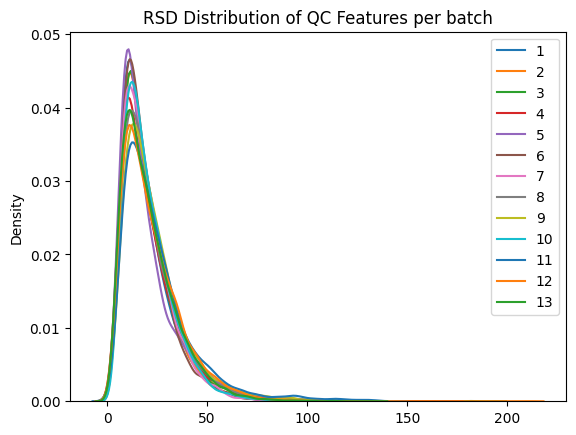

In [71]:
rsd_distribution(D,M,batch=[x for x in M['batch'].unique()])

# Plot QC Signal Against Injection Order

plotting only QC and Biological Samples
plotting only QC and Biological Samples
plotting only QC and Biological Samples


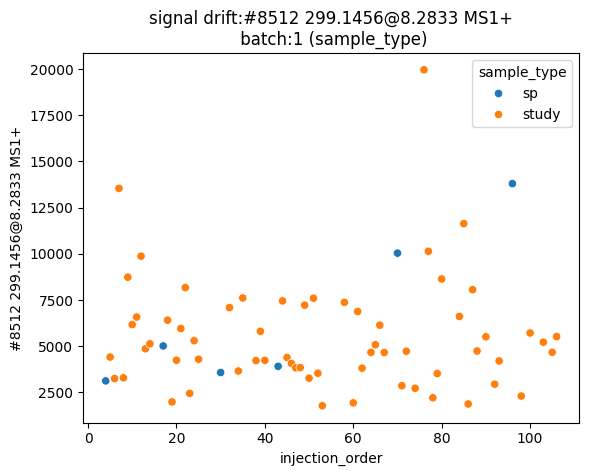

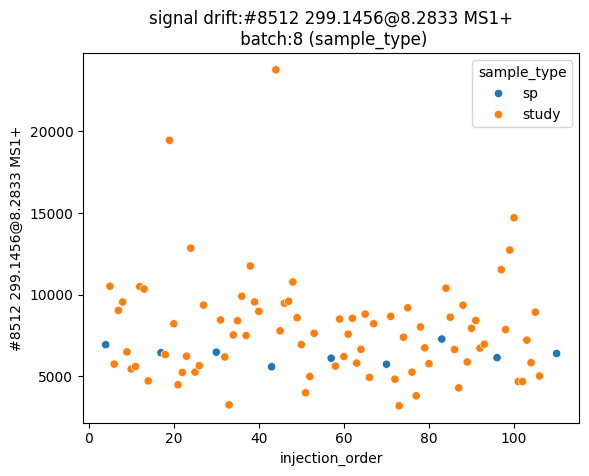

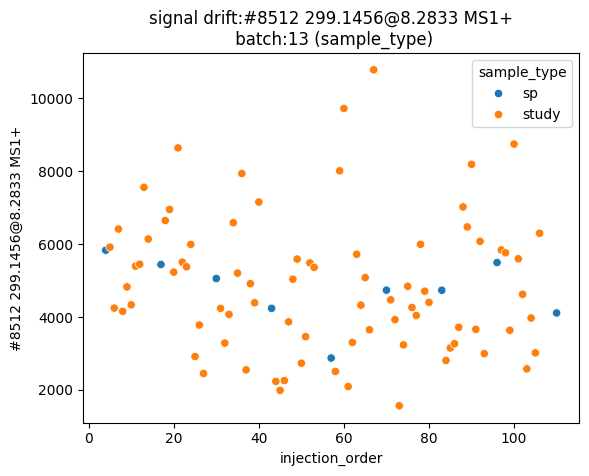

In [87]:
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,random_state=25,batch_idx=1)
plt.figure()
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,random_state=25,batch_idx=8)
plt.figure()
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,random_state=25,batch_idx=13)

# Within Batch Effect Correction: QC-SVRC
* RBF function 
* QC signal intensity ~ injection_order (QC signal intensity as a function of injection order)

In [53]:
def svr_function(qc_intensity,bio_intensity,qc_injection_order,bio_injection_order,qc1):
    params = {'kernel':['rbf'],
              'C':[C_param(qc_intensity)],
              'epsilon':[epsilon_param(qc_intensity=qc_intensity,qc1=qc1,pct_precision=15)],
              'gamma':np.logspace(-3,6,base=2)}
    if qc_intensity.isna().sum() > 5:
        return pd.concat([qc_intensity,bio_intensity],axis=0)
    else: 
        svr = SVR()
        qc_no_outliers = remove_qc_outliers(intensity=qc_intensity)
        qc_inj_no_outliers = qc_injection_order[qc_no_outliers.index]
        if qc_no_outliers.empty:
            return pd.concat([qc_intensity,bio_intensity],axis=0)
        X = qc_inj_no_outliers.to_numpy().reshape(-1,1)
        y = qc_no_outliers.to_numpy().ravel()
        cv = GridSearchCV(svr,params,n_jobs=1,scoring='neg_root_mean_squared_error',cv=LeaveOneOut())
        cv.fit(X,y)
        model = cv.best_estimator_
        fitted_values = pd.Series(model.predict(qc_injection_order.to_numpy().reshape(-1,1)),index=qc_intensity.index,name=qc_intensity.name)
        predicted_values = pd.Series(model.predict(bio_injection_order.to_numpy().reshape(-1,1)),index=bio_intensity.index,name=bio_intensity.name)
        # Kuligowski paper subtracts but how to properly remove predictions for data underneath regression curve? 
        # Could use division but would need to scale data back to original range.
        # Answer: Re-scale data using median signal intensity in qc sample, This preserves the correction while scaling the data back to an appropriate range. 
        adjusted_qc = (qc_intensity - fitted_values) + qc_intensity.median()
        adjusted_bio = (bio_intensity - predicted_values) + qc_intensity.median()
    return pd.concat([adjusted_qc,adjusted_bio],axis=0)

def remove_qc_outliers(intensity,method='median'):
    if method == 'IQR':
        Q1 = intensity.quantile(0.25)
        Q3 = intensity.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q1 - 2.5 * IQR
        lower_bound = Q3 + 2.5 * IQR
        no_outliers = intensity[(intensity > upper_bound) & (intensity < lower_bound)]
    if method == 'median':
        lower_threshold = intensity.median() * .20
        no_outliers = intensity[intensity >= lower_threshold]
    return no_outliers
def C_param(qc_intensity,lower=.10,upper=.90):
    C = qc_intensity.quantile(upper) - qc_intensity.quantile(lower)
    return C
def epsilon_param(qc_intensity,qc1,pct_precision=15):
    precision = (pct_precision / 100)
    eps = (precision / 2 )
    eps_scale = (eps * qc_intensity[qc1])
    if bool(np.isnan(eps_scale)):
        eps_scale = qc_intensity.mean() * eps
    return eps_scale

def parallel_svr_correction(data,metadata,n_jobs=-1,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        results = Parallel(n_jobs=n_jobs)(delayed(svr_function)(QC[col],Bio[col],qc_injection_order,bio_injection_order,qc1) for col in tqdm(QC.columns,desc=f'Correcting signals...'))
        #results = pd.concat(results,axis=1)
        lst.append(pd.concat(results,axis=1))
    return pd.concat(lst,axis=0)

def svr_correction(data,metadata,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        qc1 = metadata.loc[QC.index, 'injection_order'].idxmin()
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order']
        bio_injection_order = metadata.loc[Bio.index,'injection_order']
        for signal in tqdm(data.columns):
            results = svr_function(QC[signal],Bio[signal],qc_injection_order,bio_injection_order,qc1)
            lst.append(results)
    return pd.concat(lst,axis=0)



In [54]:
results = parallel_svr_correction(D.replace(128.0,np.nan),M)

Correcting signals...:   0%|          | 0/12600 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/12600 [00:00<?, ?it/s]

Correcting signals...:   0%|          | 0/12600 [00:00<?, ?it/s]

KeyboardInterrupt: 

Median RSD: 7.162962298748578
Median RSD: 6.96695159832071
Median RSD: 7.71555352466386


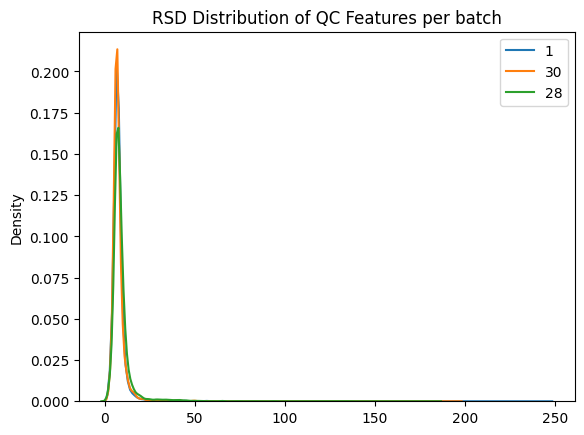

In [ ]:
rsd_distribution(results,M,batch=[x for x in M['batch'].unique()])

plotting only QC and Biological Samples
plotting only QC and Biological Samples
plotting only QC and Biological Samples


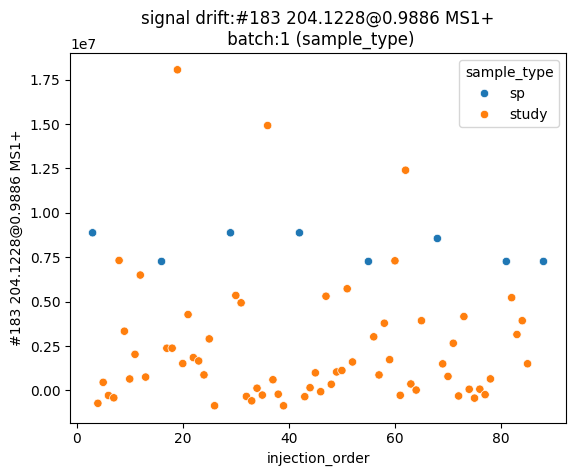

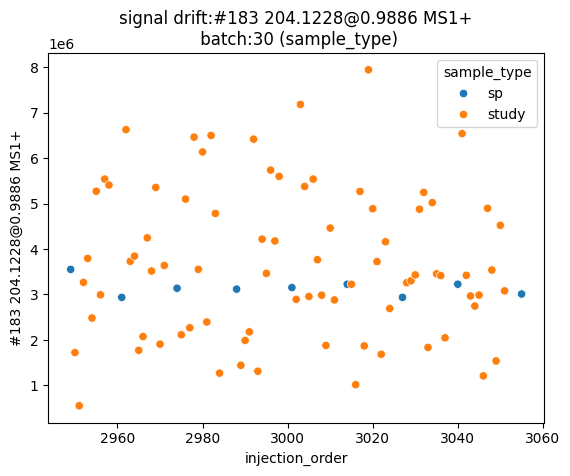

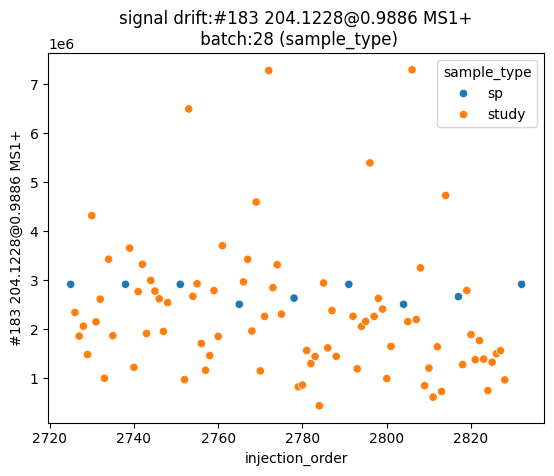

In [21]:
plot_signal_drift(data=results,metadata=M,include_all_samples=False,include_all_batches=False,signal_idx=182,batch_idx=1)
plt.figure()
plot_signal_drift(data=results,metadata=M,include_all_samples=False,include_all_batches=False,signal_idx=182,batch_idx=30)
plt.figure()
plot_signal_drift(data=results,metadata=M,include_all_samples=False,include_all_batches=False,signal_idx=182,batch_idx=28)

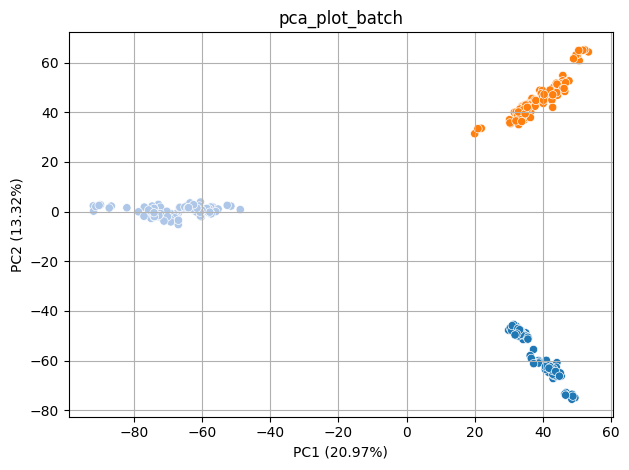

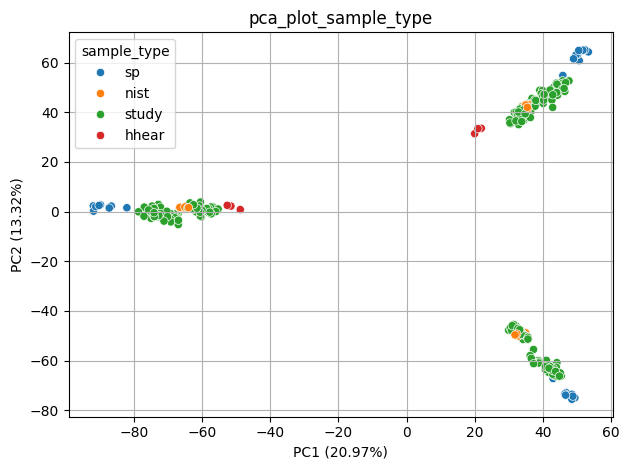

,PC1,PC2,batch,sample_type
sample_name,,,,
P_SP_000001,43.007513,-67.255345,1,sp
P_SP_000002,46.819272,-72.901487,1,sp
P_SP_000003,48.560735,-73.593008,1,sp
P_SP_000004,49.405147,-75.016537,1,sp
P_SP_000005,48.506975,-75.601992,1,sp
...,...,...,...,...
P_S_002246,40.364762,47.240197,30,study
P_S_002247,34.803400,39.419188,30,study
P_S_002248,42.915901,47.075757,30,study


In [34]:
pca_plot(TIC(results.fillna(results.min().min())),M,hues=['batch','sample_type'],plot_without_blanks=True)

# Between Batch Effect Correction : Ratio-based Method 
- scales the intensity of each metabolic feature in each sample, using a factor defined as the ratio between the median intensity in QCs in corresponsing batch and the median intensity in QCs across batches

- group by batch and take the medians across QC samples 
- group by sample type and take the median across QC samples 

- scale each signal by this ratio 

In [23]:
def ratio_based_correction(data,metadata,QC='sp'):
    D = data.copy()
    M = metadata.copy()
    QC = D.groupby(M['sample_type']).get_group(QC)
    median_across_qc = QC.median()
    median_qc_by_batch = []
    batches = M['batch'].unique()
    batch_group = QC.groupby(M['batch'])
    for batch in batches:
        median_qc_by_batch.append(batch_group.get_group(batch).median())
    scaling_factor = pd.concat(median_qc_by_batch,axis=1)
    scaling_factor.columns = M['batch'].unique()
    scaling_factor = scaling_factor.div(median_across_qc,axis=0)
    corrected_data = []
    batch_samples = D.groupby(M['batch'])
    for batch in batches:
        corrected_data.append(batch_samples.get_group(batch).mul(scaling_factor[batch],axis=1))
    corrected_data = pd.concat(corrected_data)
    corrected_data = corrected_data.loc[D.index]
    return corrected_data    
df = ratio_based_correction(D,M)

In [35]:
df = ratio_based_correction(TIC(results.fillna(results.min().min())),M)